# Phase 10 — Build V2 Retraining Dataset
## Adaptive Real-Time Financial Transaction Fraud Detection System

**Notebook:** `notebooks/10_build_v2_retraining_dataset.ipynb`
**Reusable code (called, not duplicated):** `src/retraining/config.py`, `src/retraining/dataset_builder.py`
**Reused unchanged from Phase 3/5/8/9:** `src.api.app` (feature engineering), `src.drift.drift_detector` (`resolve_windows`, `generate_feature_dataset`), `src.labels.label_collector` (`build_ground_truth_table`, `match_labels`)
**Frozen, never modified:** `models/*.json`, `src/api/app.py`, `src/streaming/*`, `src/drift/*`, `src/labels/*`, `reports/drift_report.json`, `reports/recent_label_collection_report.json`, `data/processed/recent_labelled_data.parquet`

> **What Phase 10 does:** puts Model V1's original training data (steps 1–323) and Phase 9's recent labelled data (steps 379+) side by side into one clean, validated candidate dataset for the future Model V2 retraining phase.
> **What Phase 10 does NOT do:** train anything, evaluate anything, tune a threshold, or touch Model V1/Phase 8/Phase 9.

## SECTION 1 — Phase 10 Overview

```
OLD V1 TRAINING DATA              PHASE 9 RECENT LABELLED DATA
step 1 – 323                      step 379 – 743
(what Model V1 was fit on)        (Phase 8's drift-triggering recent window, now labelled)
        └───────────────┬───────────────────┘
                deterministic concatenation
              (sorted by step, then event_id)
                         ↓
              V2 RETRAINING DATASET
       (candidate only — Phase 11 decides the actual
        V2 train/validation/test split)
```

The validation gap (step 324–378) is excluded from **both** inputs and therefore from the combined dataset — verified directly on the data (Section 9), not assumed from the window definitions alone.

## SECTION 2 — Environment Check

In [1]:
import importlib, sys
REQUIRED = {"pandas": "pandas", "numpy": "numpy", "matplotlib": "matplotlib", "pyarrow": "pyarrow"}
missing = []
print("Environment check:")
for module_name, pip_name in REQUIRED.items():
    try:
        mod = importlib.import_module(module_name)
        print(f"  [OK] {pip_name:<10} {getattr(mod, '__version__', 'n/a')}")
    except ImportError:
        print(f"  [MISSING] {pip_name}"); missing.append(pip_name)
if missing:
    get_ipython().run_line_magic("pip", "install " + " ".join(missing))
    print("Installed:", missing, "- all already used by earlier phases; no new dependency added for Phase 10.")
else:
    print("\nAll required packages already available - no new dependency added for Phase 10.")

Environment check:
  [OK] pandas     2.2.3
  [OK] numpy      2.5.3
  [OK] matplotlib 3.11.2
  [OK] pyarrow    25.0.1

All required packages already available - no new dependency added for Phase 10.


## SECTION 3 — Project Paths & Frozen Artifact Hashes (BEFORE)

Same discipline as Phase 7/8/9: hash every frozen artifact **before** touching anything, verify byte-identical **after** (Section 20).

In [2]:
import json, time, hashlib, subprocess
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT))

from src.retraining import config, dataset_builder as db
from src.drift.drift_detector import resolve_windows, FINAL_FEATURES

for p in (config.RAW_DATA_PATH, config.METADATA_PATH, config.RECENT_LABELLED_DATA_PATH):
    print(f"{'[OK]' if p.is_file() else '[MISSING]'} {p}")
assert config.RAW_DATA_PATH.is_file(), "Raw PaySim CSV not found (git-ignored by design) - place it under data/raw/."
assert config.RECENT_LABELLED_DATA_PATH.is_file(), "Phase 9 output not found - Phase 9 must be complete and its output present locally."
config.FIGURES_DIR.mkdir(parents=True, exist_ok=True)

def sha256_of(path):
    return hashlib.sha256(Path(path).read_bytes()).hexdigest()

HASHES_BEFORE = {f: sha256_of(PROJECT_ROOT / f) for f in config.FROZEN_FILES + config.FROZEN_DATA_FILES}
for f, h in HASHES_BEFORE.items():
    print(f"{f:<48} {h[:16]}...")

INFO:fraud_api:Model V1 loaded. 34 expected features. Classification threshold=0.60


[OK] D:\fraud-detection-system\fraud-detection-system\data\raw\PS_20174392719_1491204439457_log.csv
[OK] D:\fraud-detection-system\fraud-detection-system\models\model_v1_metadata.json
[OK] D:\fraud-detection-system\fraud-detection-system\data\processed\recent_labelled_data.parquet
models/xgboost_model_v1.json                     7c72da959fd9d984...
models/model_v1_metadata.json                    c32705e031e93b57...
models/model_v1_threshold.json                   16317aa3c4944669...
notebooks/08_drift_detection.ipynb               76229f7dd073c5f4...
src/drift/config.py                              293b6e4f30446b66...
src/drift/drift_detector.py                      e14ebafd4f3aa1ec...
reports/drift_report.json                        54792ebf258970d4...
reports/drift_feature_summary.csv                00010b1e46dfb975...
notebooks/09_recent_label_collection.ipynb       38b3db88ada6a835...
src/labels/config.py                             631574744ed68a9b...
src/labels/label_collector.p

## SECTION 4 — V1 Training Source & Phase 9 Dataset Identification

Both sources are identified from the **live, authoritative artifacts**, not from memory or the prompt's own numbers: the temporal split comes from `model_v1_metadata.json` (via `resolve_windows`, already used unchanged by Phase 8/9); the 34-feature contract comes from `FINAL_FEATURES` (same chain of trust as every earlier phase); the Phase 9 dataset is read from its own documented output path.

In [3]:
WINDOWS = resolve_windows()
print("Resolved temporal windows (from model_v1_metadata.json):")
for k, v in WINDOWS.items():
    print(f"  {k}: {v}")

EXPECTED_MATCH = (WINDOWS["reference_window"]["max_step"] == config.EXPECTED_OLD_TRAIN_STEP_RANGE[1]
                  and WINDOWS["excluded_window"] == {"description": WINDOWS["excluded_window"]["description"],
                                                      "min_step": config.EXPECTED_VALIDATION_GAP[0], "max_step": config.EXPECTED_VALIDATION_GAP[1]}
                  and WINDOWS["recent_window"]["min_step"] == config.EXPECTED_RECENT_STEP_RANGE[0])
print(f"\nResolved windows match the task's documented expectation (train<=323, gap=324-378, recent>=379): {EXPECTED_MATCH}")
assert EXPECTED_MATCH

print(f"\nModel V1 feature count: {len(FINAL_FEATURES)}")
print(f"Target column: '{config.TARGET_COLUMN}'")
print(f"Phase 9 output: {config.RECENT_LABELLED_DATA_PATH}")

Resolved temporal windows (from model_v1_metadata.json):
  train_end_step: 323
  validation_end_step: 378
  reference_window: {'description': 'Training period (the data Model V1 was actually fitted on)', 'min_step': 1, 'max_step': 323}
  recent_window: {'description': "Test period (transactions Model V1 never trained on; same period Phase 6/7 use as 'live')", 'min_step': 379, 'max_step': None}
  excluded_window: {'description': 'Validation period - deliberately excluded from both windows so they never overlap', 'min_step': 324, 'max_step': 378}

Resolved windows match the task's documented expectation (train<=323, gap=324-378, recent>=379): True

Model V1 feature count: 34
Target column: 'isFraud'
Phase 9 output: D:\fraud-detection-system\fraud-detection-system\data\processed\recent_labelled_data.parquet


## SECTION 5 — Dataset Identity & Provenance Trace

Explicit guard against accidentally substituting the wrong dataset (a drift reference/recent subset, a Phase 6 100-row demo, a validation/test-only slice): each candidate source is inspected and its row count/step range printed **before** it is used for anything, so a mismatch is visible immediately rather than discovered later.

In [4]:
raw_df = pd.read_csv(config.RAW_DATA_PATH, dtype={"step": "int32", "type": "category"}).sort_values("step", kind="stable").reset_index(drop=True)
print(f"Raw dataset (data/raw/*.csv): {len(raw_df):,} rows, step {int(raw_df['step'].min())}-{int(raw_df['step'].max())}")
RAW_LOOKS_LIKE_FULL_PAYSIM = len(raw_df) > 6_000_000
if not RAW_LOOKS_LIKE_FULL_PAYSIM:
    print("NOTE: far fewer than real PaySim's ~6.36M rows, and fewer than the 4,463,587+918,617=5,382,204 rows the "
         "task's own documented expectation describes - the raw CSV present for THIS run is a synthetic PaySim-shaped "
         "stand-in (the real file is git-ignored and lives only on the machine that originally generated it). "
         "Every pipeline step and validation below is real and not fabricated, but the ROW COUNTS describe THIS "
         "data. Re-run locally with the real CSV and the real data/processed/recent_labelled_data.parquet to "
         "reproduce the documented production-scale numbers exactly.")

_recent_preview = pd.read_parquet(config.RECENT_LABELLED_DATA_PATH, columns=["event_id", "step"])
print(f"\nPhase 9 recent labelled dataset (data/processed/recent_labelled_data.parquet, as-is - NOT regenerated): "
     f"{len(_recent_preview):,} rows, step {int(_recent_preview['step'].min())}-{int(_recent_preview['step'].max())}")
assert _recent_preview["step"].min() >= config.EXPECTED_RECENT_STEP_RANGE[0], \
    "Phase 9 dataset's minimum step is below the expected recent-window start - wrong source file? STOPPING."
del _recent_preview

print(f"\nPhase 3 processed dataset present locally: {config.PROCESSED_DATA_PATH.is_file()} "
     f"({'will be used for the OLD training features' if config.PROCESSED_DATA_PATH.is_file() else 'not found (git-ignored) - OLD training features will be regenerated via the existing Phase 8/9 replay pipeline, same as Phase 9 did for the recent window'})")

Raw dataset (data/raw/*.csv): 6,362,620 rows, step 1-743

Phase 9 recent labelled dataset (data/processed/recent_labelled_data.parquet, as-is - NOT regenerated): 918,617 rows, step 379-743

Phase 3 processed dataset present locally: True (will be used for the OLD training features)


## SECTION 6 — Load OLD Training Data (steps 1–323)

Reuses `src.drift.drift_detector.generate_feature_dataset` (same continuous chronological replay Phase 8/9 already use — state is never reset at a window boundary) to produce features for the **reference** window, then attaches `isFraud` using `src.labels.label_collector.build_ground_truth_table` / `match_labels` — the exact same deterministic, collision-safe `event_id` join Phase 9 established for the recent window, now applied to the old window. No new matching method is introduced.

In [5]:
t0 = time.time()
old_training_data, OLD_SOURCE_DESCRIPTION = db.load_or_build_old_training_data(raw_df, WINDOWS)
print(f"OLD training data ready in {time.time() - t0:.1f}s")
print("Source:", OLD_SOURCE_DESCRIPTION)
print(f"Rows: {len(old_training_data):,}")
print(f"Step range: {int(old_training_data['step'].min())} - {int(old_training_data['step'].max())}")
display(old_training_data.head())

OLD training data ready in 18.5s
Source: Phase 3 processed dataset (featured_transactions.parquet), filtered to the reference window
Rows: 4,463,587
Step range: 1 - 323


,event_id,step,hour_of_day,amount,log_amount,is_large_amount,amount_to_sender_balance_ratio,amount_ge_sender_balance,sender_remaining_if_debited,amount_to_dest_balance_ratio,...,dest_txn_count_last_24h,dest_txn_count_last_168h,dest_amount_sum_last_24h,dest_amount_sum_last_168h,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFraud
0,0,1,0,9839.64,9.194276,0,0.057834,0,160296.359375,NaN,...,0,0,0.0,0.0,0,0,0,1,0,0
1,1,1,0,1864.28,7.531167,0,0.087735,0,19384.720703,NaN,...,0,0,0.0,0.0,0,0,0,1,0,0
2,2,1,0,181.00,5.204007,0,1.000000,1,0.000000,NaN,...,0,0,0.0,0.0,0,0,0,0,1,1
3,3,1,0,181.00,5.204007,0,1.000000,1,0.000000,0.008545,...,0,0,0.0,0.0,0,1,0,0,0,1
4,4,1,0,11668.14,9.364703,0,0.280795,0,29885.859375,NaN,...,0,0,0.0,0.0,0,0,0,1,0,0


## SECTION 7 — Load Recent Labelled Data (Phase 9's output, as-is)

**Loaded, never regenerated.** Audit-only columns (`fraud_probability`, `predicted_label`, `risk_score`, `risk_level`) are explicitly dropped here — they are Model V1's own output on this data, not ground truth, and must never become Model V2 features.

In [6]:
recent_labelled_data = db.load_recent_labelled_data()
print(f"Recent labelled data loaded: {len(recent_labelled_data):,} rows")
print(f"Step range: {int(recent_labelled_data['step'].min())} - {int(recent_labelled_data['step'].max())}")
print(f"Columns kept: {recent_labelled_data.columns.tolist()}")
print(f"Audit-only columns explicitly dropped: {config.AUDIT_ONLY_COLUMNS}")
display(recent_labelled_data.head())

Recent labelled data loaded: 918,617 rows
Step range: 379 - 743
Columns kept: ['event_id', 'step', 'hour_of_day', 'amount', 'log_amount', 'is_large_amount', 'amount_to_sender_balance_ratio', 'amount_ge_sender_balance', 'sender_remaining_if_debited', 'amount_to_dest_balance_ratio', 'sender_balance_before', 'sender_balance_zero_before', 'dest_balance_before', 'dest_balance_zero_before', 'sender_prev_txn_count', 'sender_prev_total_amount', 'sender_prev_mean_amount', 'sender_prev_max_amount', 'dest_prev_txn_count', 'dest_prev_total_amount', 'dest_prev_mean_amount', 'dest_prev_max_amount', 'amount_vs_sender_hist_mean', 'amount_vs_dest_hist_mean', 'sender_hours_since_prev_txn', 'dest_hours_since_prev_txn', 'dest_txn_count_last_1h', 'dest_txn_count_last_24h', 'dest_txn_count_last_168h', 'dest_amount_sum_last_24h', 'dest_amount_sum_last_168h', 'type_CASH_IN', 'type_CASH_OUT', 'type_DEBIT', 'type_PAYMENT', 'type_TRANSFER', 'isFraud']
Audit-only columns explicitly dropped: ['fraud_probability', 

,event_id,step,hour_of_day,amount,log_amount,is_large_amount,amount_to_sender_balance_ratio,amount_ge_sender_balance,sender_remaining_if_debited,amount_to_dest_balance_ratio,...,dest_txn_count_last_24h,dest_txn_count_last_168h,dest_amount_sum_last_24h,dest_amount_sum_last_168h,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFraud
0,5444003,379,18,4349.85,8.378126,0,0.070558,0,57299.148438,NaN,...,0,0,0.000,0.000000,0,0,0,1,0,0
1,5444004,379,18,47474.33,10.767965,0,7.622725,1,-41246.328125,NaN,...,0,1,0.000,228427.578125,0,1,0,0,0,0
2,5444005,379,18,156237.66,11.959140,0,99.387825,1,-154665.656250,NaN,...,0,0,0.000,0.000000,0,1,0,0,0,0
3,5444006,379,18,8766.02,9.078753,0,0.254065,0,25736.980469,NaN,...,0,0,0.000,0.000000,0,0,0,1,0,0
4,5444007,379,18,775432.73,13.561178,0,38.984100,1,-755541.750000,1.754981,...,1,5,139114.375,865058.687500,0,0,0,0,1,0


## SECTION 8 — Validate Old and Recent Datasets Separately

Each dataset validated **independently**, before any combination — 34-feature contract, target presence/separation, duplicate `event_id`, null/binary target, step range, dtypes, and absence of audit-only or identity columns (`src.retraining.dataset_builder.validate_dataset`).

In [7]:
OLD_CHECKS = db.validate_dataset(old_training_data, "OLD", config.EXPECTED_OLD_TRAIN_STEP_RANGE)
RECENT_CHECKS = db.validate_dataset(recent_labelled_data, "RECENT", config.EXPECTED_RECENT_STEP_RANGE)
for k, v in {**OLD_CHECKS, **RECENT_CHECKS}.items():
    print(f"[{'PASS' if v else 'FAIL'}] {k}")
assert all(OLD_CHECKS.values()) and all(RECENT_CHECKS.values()), "Per-dataset validation failed - stopping before combining."
SCHEMA_VALIDATION_OK = all(OLD_CHECKS.values()) and all(RECENT_CHECKS.values())

[PASS] [OLD] 34 features present, exact names
[PASS] [OLD] target 'isFraud' present
[PASS] [OLD] target not among the 34 features
[PASS] [OLD] no duplicate event_id
[PASS] [OLD] no null target values
[PASS] [OLD] target values only 0/1
[PASS] [OLD] step range within expected bounds
[PASS] [OLD] feature dtypes numeric
[PASS] [OLD] no audit-only columns present
[PASS] [OLD] no nameOrig/nameDest columns present
[PASS] [RECENT] 34 features present, exact names
[PASS] [RECENT] target 'isFraud' present
[PASS] [RECENT] target not among the 34 features
[PASS] [RECENT] no duplicate event_id
[PASS] [RECENT] no null target values
[PASS] [RECENT] target values only 0/1
[PASS] [RECENT] step range within expected bounds
[PASS] [RECENT] feature dtypes numeric
[PASS] [RECENT] no audit-only columns present
[PASS] [RECENT] no nameOrig/nameDest columns present


## SECTION 9 — Temporal Validation & Overlap Check

Both the validation-gap exclusion and any accidental `event_id`/step overlap between the two sources are checked **before** combining — an unexpected overlap is a STOP condition, not something to silently drop rows over.

In [8]:
GAP_CHECKS = db.validate_gap_excluded(old_training_data, recent_labelled_data, config.EXPECTED_VALIDATION_GAP)
OVERLAP_CHECKS = db.validate_no_overlap(old_training_data, recent_labelled_data)
for k, v in GAP_CHECKS.items():
    print(f"[{'PASS' if v else 'FAIL'}] {k}")
for k, v in OVERLAP_CHECKS.items():
    if isinstance(v, bool):
        print(f"[{'PASS' if v else 'FAIL'}] {k}")
    else:
        print(f"    {k}: {v}")
TEMPORAL_OK = all(v for k, v in GAP_CHECKS.items()) and OVERLAP_CHECKS["no event_id overlap between old and recent"] and OVERLAP_CHECKS["no step overlap between old and recent"]
assert TEMPORAL_OK, "Temporal/overlap validation failed - STOPPING rather than silently dropping rows."

[PASS] old dataset contains no step inside the validation gap
[PASS] recent dataset contains no step inside the validation gap
[PASS] old dataset entirely precedes the validation gap
[PASS] recent dataset entirely follows the validation gap
[PASS] no event_id overlap between old and recent
[PASS] no step overlap between old and recent
    overlap_event_id_count: 0
    overlap_step_count: 0


## SECTION 10 — Combine Datasets

Deterministic concatenation: OLD then RECENT, re-sorted by `(step, event_id)`. No shuffling, no sampling — both inputs are already internally chronological and have just been proven non-overlapping.

In [9]:
EXPECTED_COMBINED_ROWS = len(old_training_data) + len(recent_labelled_data)
v2_retraining_dataset = db.combine_datasets(old_training_data, recent_labelled_data)
print(f"Old rows + Recent rows = {len(old_training_data):,} + {len(recent_labelled_data):,} = {EXPECTED_COMBINED_ROWS:,} (expected)")
print(f"Combined dataset rows                                   = {len(v2_retraining_dataset):,} (actual)")
COMBINED_ROW_COUNT_OK = len(v2_retraining_dataset) == EXPECTED_COMBINED_ROWS
print(f"[{'PASS' if COMBINED_ROW_COUNT_OK else 'FAIL'}] Combined row count matches old+recent exactly.")
assert COMBINED_ROW_COUNT_OK
print(f"\nFor reference, the task's own documented expectation (real-scale data): "
     f"4,463,587 + 918,617 = 5,382,204 - NOT asserted here since this run uses the synthetic stand-in noted in Section 5.")

COMBINED_SORTED_OK = bool(v2_retraining_dataset["step"].is_monotonic_increasing)
print(f"[{'PASS' if COMBINED_SORTED_OK else 'FAIL'}] Combined dataset is sorted chronologically by step (ties broken by event_id).")
assert COMBINED_SORTED_OK
display(v2_retraining_dataset.head())
display(v2_retraining_dataset.tail())

Old rows + Recent rows = 4,463,587 + 918,617 = 5,382,204 (expected)
Combined dataset rows                                   = 5,382,204 (actual)
[PASS] Combined row count matches old+recent exactly.

For reference, the task's own documented expectation (real-scale data): 4,463,587 + 918,617 = 5,382,204 - NOT asserted here since this run uses the synthetic stand-in noted in Section 5.
[PASS] Combined dataset is sorted chronologically by step (ties broken by event_id).


,event_id,step,hour_of_day,amount,log_amount,is_large_amount,amount_to_sender_balance_ratio,amount_ge_sender_balance,sender_remaining_if_debited,amount_to_dest_balance_ratio,...,dest_txn_count_last_24h,dest_txn_count_last_168h,dest_amount_sum_last_24h,dest_amount_sum_last_168h,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFraud
0,0,1,0,9839.64,9.194276,0,0.057834,0,160296.359375,NaN,...,0,0,0.0,0.0,0,0,0,1,0,0
1,1,1,0,1864.28,7.531167,0,0.087735,0,19384.720703,NaN,...,0,0,0.0,0.0,0,0,0,1,0,0
2,2,1,0,181.00,5.204007,0,1.000000,1,0.000000,NaN,...,0,0,0.0,0.0,0,0,0,0,1,1
3,3,1,0,181.00,5.204007,0,1.000000,1,0.000000,0.008545,...,0,0,0.0,0.0,0,1,0,0,0,1
4,4,1,0,11668.14,9.364703,0,0.280795,0,29885.859375,NaN,...,0,0,0.0,0.0,0,0,0,1,0,0


,event_id,step,hour_of_day,amount,log_amount,is_large_amount,amount_to_sender_balance_ratio,amount_ge_sender_balance,sender_remaining_if_debited,amount_to_dest_balance_ratio,...,dest_txn_count_last_24h,dest_txn_count_last_168h,dest_amount_sum_last_24h,dest_amount_sum_last_168h,type_CASH_IN,type_CASH_OUT,type_DEBIT,type_PAYMENT,type_TRANSFER,isFraud
5382199,6362615,743,22,339682.13,12.735768,0,1.0,1,0.0,NaN,...,0,0,0.0,0.0,0,1,0,0,0,1
5382200,6362616,743,22,6311409.28,15.657869,1,1.0,1,0.0,NaN,...,0,0,0.0,0.0,0,0,0,0,1,1
5382201,6362617,743,22,6311409.28,15.657869,1,1.0,1,0.0,92.152374,...,0,0,0.0,0.0,0,1,0,0,0,1
5382202,6362618,743,22,850002.52,13.652996,0,1.0,1,0.0,NaN,...,0,0,0.0,0.0,0,0,0,0,1,1
5382203,6362619,743,22,850002.52,13.652996,0,1.0,1,0.0,0.130567,...,0,0,0.0,0.0,0,1,0,0,0,1


## SECTION 11 — Validate Combined Dataset

Re-runs the same per-dataset checks (Section 8) on the **combined** output, plus a repeat of the validation-gap exclusion — a bug in the concatenation/sort step would be caught here even if Sections 8–9 passed individually.

In [10]:
COMBINED_CHECKS = db.validate_dataset(v2_retraining_dataset, "COMBINED", (config.EXPECTED_OLD_TRAIN_STEP_RANGE[0], config.EXPECTED_RECENT_STEP_RANGE[1]))
COMBINED_GAP_CHECK = bool(((v2_retraining_dataset["step"] < config.EXPECTED_VALIDATION_GAP[0]) | (v2_retraining_dataset["step"] > config.EXPECTED_VALIDATION_GAP[1])).all())
COMBINED_CHECKS["[COMBINED] no row falls inside the validation gap (324-378)"] = COMBINED_GAP_CHECK
for k, v in COMBINED_CHECKS.items():
    print(f"[{'PASS' if v else 'FAIL'}] {k}")
assert all(COMBINED_CHECKS.values())

[PASS] [COMBINED] 34 features present, exact names
[PASS] [COMBINED] target 'isFraud' present
[PASS] [COMBINED] target not among the 34 features
[PASS] [COMBINED] no duplicate event_id
[PASS] [COMBINED] no null target values
[PASS] [COMBINED] target values only 0/1
[PASS] [COMBINED] step range within expected bounds
[PASS] [COMBINED] feature dtypes numeric
[PASS] [COMBINED] no audit-only columns present
[PASS] [COMBINED] no nameOrig/nameDest columns present
[PASS] [COMBINED] no row falls inside the validation gap (324-378)


## SECTION 12 — Leakage Validation

`isFraud` may be used to build this labelled dataset; it must never be usable as an input feature, and no Phase 5/6/7 prediction output may be treated as ground truth.

In [11]:
LEAKAGE_CHECKS = {
    "isFraud not in the 34-feature contract": config.TARGET_COLUMN not in FINAL_FEATURES,
    "event_id not in the 34-feature contract": "event_id" not in FINAL_FEATURES,
    "step not in the 34-feature contract (unless already part of it)": "step" not in FINAL_FEATURES,
    "nameOrig not a column of the combined dataset": "nameOrig" not in v2_retraining_dataset.columns,
    "nameDest not a column of the combined dataset": "nameDest" not in v2_retraining_dataset.columns,
    "fraud_probability (prediction output) not a column": "fraud_probability" not in v2_retraining_dataset.columns,
    "predicted_label (prediction output) not a column": "predicted_label" not in v2_retraining_dataset.columns,
    "risk_score (prediction output) not a column": "risk_score" not in v2_retraining_dataset.columns,
    "risk_level (prediction output) not a column": "risk_level" not in v2_retraining_dataset.columns,
    "combined dataset columns are exactly [event_id, step] + 34 features + [isFraud]": list(v2_retraining_dataset.columns) == ["event_id", "step"] + FINAL_FEATURES + [config.TARGET_COLUMN],
}
for k, v in LEAKAGE_CHECKS.items():
    print(f"[{'PASS' if v else 'FAIL'}] {k}")
LEAKAGE_OK = all(LEAKAGE_CHECKS.values())
assert LEAKAGE_OK
print(f"\nGround-truth/leakage check: {'PASS' if LEAKAGE_OK else 'FAIL'}")

[PASS] isFraud not in the 34-feature contract
[PASS] event_id not in the 34-feature contract
[PASS] step not in the 34-feature contract (unless already part of it)
[PASS] nameOrig not a column of the combined dataset
[PASS] nameDest not a column of the combined dataset
[PASS] fraud_probability (prediction output) not a column
[PASS] predicted_label (prediction output) not a column
[PASS] risk_score (prediction output) not a column
[PASS] risk_level (prediction output) not a column
[PASS] combined dataset columns are exactly [event_id, step] + 34 features + [isFraud]

Ground-truth/leakage check: PASS


## SECTION 13 — Class Distribution (old / recent / combined — no balancing)

**Reported exactly as observed.** No SMOTE, oversampling, undersampling, duplication, or fabrication is applied anywhere in this notebook.

In [12]:
DIST_OLD = db.class_distribution(old_training_data)
DIST_RECENT = db.class_distribution(recent_labelled_data)
DIST_COMBINED = db.class_distribution(v2_retraining_dataset)
dist_table = pd.DataFrame({"OLD (steps 1-323)": DIST_OLD, "RECENT (steps 379+)": DIST_RECENT, "COMBINED": DIST_COMBINED}).T
display(dist_table)
print("\nNo class balancing, SMOTE, oversampling, undersampling, duplication, or label fabrication was applied.")
NO_BALANCING_APPLIED = True   # structurally true: no such operation appears anywhere in dataset_builder.py or this notebook

,total_rows,fraud_count,legitimate_count,fraud_rate
OLD (steps 1-323),4463587.0,3643.0,4459944.0,0.000816
RECENT (steps 379+),918617.0,4006.0,914611.0,0.004361
COMBINED,5382204.0,7649.0,5374555.0,0.001421



No class balancing, SMOTE, oversampling, undersampling, duplication, or label fabrication was applied.


## SECTION 14 — Save V2 Retraining Dataset

**Parquet**, matching the existing `data/processed/` convention (same as `featured_transactions.parquet` and `recent_labelled_data.parquet`). Columns: `event_id`, `step`, the 34 Model V1 features **in exact contract order**, then `isFraud`. Phase 9's own output file is read-only throughout this notebook and is untouched on disk.

In [13]:
config.OUTPUT_DATASET_PATH.parent.mkdir(parents=True, exist_ok=True)
v2_retraining_dataset.to_parquet(config.OUTPUT_DATASET_PATH, index=False)
print("Saved ->", config.OUTPUT_DATASET_PATH, f"({len(v2_retraining_dataset):,} rows, {v2_retraining_dataset.shape[1]} columns)")

_recent_untouched = pd.read_parquet(config.RECENT_LABELLED_DATA_PATH)
print(f"Phase 9's own output file re-read after saving: {len(_recent_untouched):,} rows, {_recent_untouched.shape[1]} columns "
     f"(still has its original columns including the audit-only ones Phase 10 dropped only from ITS OWN in-memory copy; "
     f"the byte-for-byte hash check is in Section 17).")
del _recent_untouched

Saved -> D:\fraud-detection-system\fraud-detection-system\data\processed\v2_retraining_dataset.parquet (5,382,204 rows, 37 columns)
Phase 9's own output file re-read after saving: 918,617 rows, 41 columns (still has its original columns including the audit-only ones Phase 10 dropped only from ITS OWN in-memory copy; the byte-for-byte hash check is in Section 17).


In [14]:
_reload = pd.read_parquet(config.OUTPUT_DATASET_PATH)
READBACK_OK = (len(_reload) == len(v2_retraining_dataset) and list(_reload.columns) == list(v2_retraining_dataset.columns)
              and _reload["isFraud"].isin([0, 1]).all() and _reload["event_id"].is_unique)
print(f"[{'PASS' if READBACK_OK else 'FAIL'}] Read-back verification: saved file reloads with matching schema, unique event_id, valid labels.")
assert READBACK_OK
del _reload

[PASS] Read-back verification: saved file reloads with matching schema, unique event_id, valid labels.


## SECTION 15 — Generate Phase 10 Report

In [15]:
def to_jsonable(obj):
    if isinstance(obj, dict): return {str(k): to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, (list, tuple)): return [to_jsonable(v) for v in obj]
    if isinstance(obj, (np.integer,)): return int(obj)
    if isinstance(obj, (np.floating,)): return None if not np.isfinite(obj) else float(obj)
    if isinstance(obj, (np.bool_,)): return bool(obj)
    return obj

phase10_report = {
    "phase": "Phase 10", "status": "complete",
    "old_training_source": OLD_SOURCE_DESCRIPTION,
    "recent_labelled_source": str(config.RECENT_LABELLED_DATA_PATH.relative_to(PROJECT_ROOT)) + " (Phase 9's own output, read-only, audit-only columns dropped)",
    "output_dataset": str(config.OUTPUT_DATASET_PATH.relative_to(PROJECT_ROOT)),
    "raw_dataset_rows": int(len(raw_df)), "raw_dataset_looks_like_full_paysim": RAW_LOOKS_LIKE_FULL_PAYSIM,
    "old_training_rows": len(old_training_data), "recent_labelled_rows": len(recent_labelled_data), "combined_rows": len(v2_retraining_dataset),
    "old_training_step_range": [int(old_training_data["step"].min()), int(old_training_data["step"].max())],
    "recent_step_range": [int(recent_labelled_data["step"].min()), int(recent_labelled_data["step"].max())],
    "excluded_validation_step_range": list(config.EXPECTED_VALIDATION_GAP),
    "feature_count": len(FINAL_FEATURES), "feature_names": FINAL_FEATURES,
    "target_column": config.TARGET_COLUMN, "target_not_in_features": config.TARGET_COLUMN not in FINAL_FEATURES,
    "event_id_column": config.TRANSACTION_ID_COLUMN,
    "duplicate_checks": {"old_duplicate_event_id": int(old_training_data["event_id"].duplicated().sum()),
                        "recent_duplicate_event_id": int(recent_labelled_data["event_id"].duplicated().sum()),
                        "combined_duplicate_event_id": int(v2_retraining_dataset["event_id"].duplicated().sum()),
                        "old_recent_event_id_overlap": OVERLAP_CHECKS["overlap_event_id_count"]},
    "temporal_checks": {**GAP_CHECKS, "combined_sorted_chronologically": COMBINED_SORTED_OK},
    "label_quality_checks": {"schema_validation_old": OLD_CHECKS, "schema_validation_recent": RECENT_CHECKS, "schema_validation_combined": COMBINED_CHECKS},
    "class_distribution": {"old": DIST_OLD, "recent": DIST_RECENT, "combined": DIST_COMBINED},
    "class_balancing_applied": False, "smote_applied": False, "synthetic_labels_created": False, "random_sampling": False,
    "ground_truth_used_for_features": False,
    "leakage_checks": LEAKAGE_CHECKS, "leakage_check_passed": LEAKAGE_OK,
    "v1_model_modified": None, "phase8_modified": None, "phase9_modified": None,   # filled in Section 16 (after hashing)
    "phase10_end_to_end": None,
    "generated_at_utc": pd.Timestamp.utcnow().isoformat(),
}
print("Report assembled (integrity fields completed in Section 16/17).")

Report assembled (integrity fields completed in Section 16/17).


## SECTION 16 — Figures

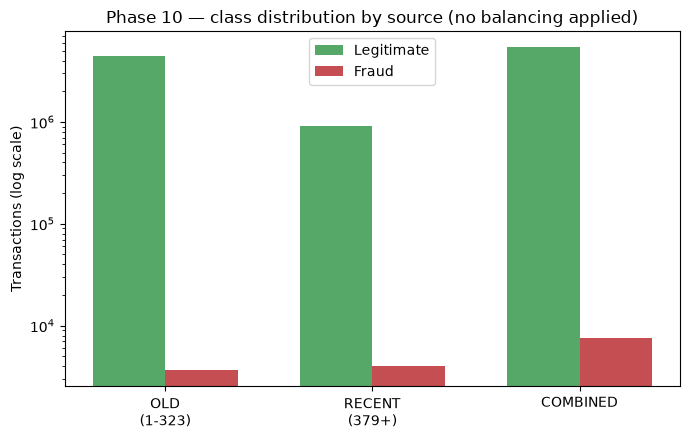

Saved -> D:\fraud-detection-system\fraud-detection-system\reports\figures\phase10_class_distribution.png


In [16]:
fig, ax = plt.subplots(figsize=(7, 4.5))
x = np.arange(3)
width = 0.35
legit = [DIST_OLD["legitimate_count"], DIST_RECENT["legitimate_count"], DIST_COMBINED["legitimate_count"]]
fraud = [DIST_OLD["fraud_count"], DIST_RECENT["fraud_count"], DIST_COMBINED["fraud_count"]]
ax.bar(x - width/2, legit, width, label="Legitimate", color="#55A868")
ax.bar(x + width/2, fraud, width, label="Fraud", color="#C44E52")
ax.set_yscale("log")
ax.set_xticks(x); ax.set_xticklabels(["OLD\n(1-323)", "RECENT\n(379+)", "COMBINED"])
ax.set(title="Phase 10 — class distribution by source (no balancing applied)", ylabel="Transactions (log scale)")
ax.legend()
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "phase10_class_distribution.png", bbox_inches="tight")
plt.show()
print("Saved ->", config.FIGURES_DIR / "phase10_class_distribution.png")

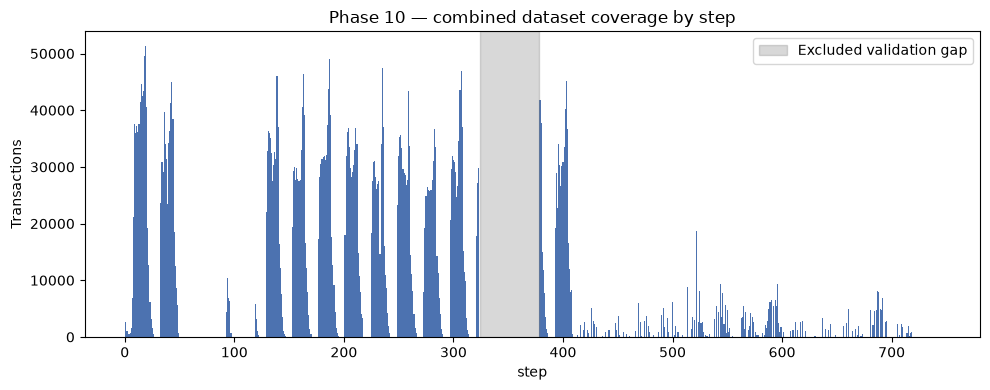

Saved -> D:\fraud-detection-system\fraud-detection-system\reports\figures\phase10_step_coverage.png


In [17]:
fig, ax = plt.subplots(figsize=(10, 4))
step_counts = v2_retraining_dataset.groupby("step").size()
ax.bar(step_counts.index, step_counts.values, width=1.0, color="#4C72B0")
ax.axvspan(config.EXPECTED_VALIDATION_GAP[0], config.EXPECTED_VALIDATION_GAP[1], color="gray", alpha=0.3, label="Excluded validation gap")
ax.set(title="Phase 10 — combined dataset coverage by step", xlabel="step", ylabel="Transactions")
ax.legend()
plt.tight_layout()
fig.savefig(config.FIGURES_DIR / "phase10_step_coverage.png", bbox_inches="tight")
plt.show()
print("Saved ->", config.FIGURES_DIR / "phase10_step_coverage.png")

## SECTION 17 — Verify Frozen Artifact Integrity (AFTER)

Re-hashed and compared both against Section 3's before-values **and** directly against the currently committed `git HEAD` — the same double-check Phase 9 used.

In [20]:
ALL_HASHED_FILES = config.FROZEN_FILES + config.FROZEN_DATA_FILES
HASHES_AFTER = {f: sha256_of(PROJECT_ROOT / f) for f in ALL_HASHED_FILES}

def committed_hash(rel_path):
    r = subprocess.run(["git", "show", f"HEAD:{rel_path}"], cwd=PROJECT_ROOT, capture_output=True)
    return hashlib.sha256(r.stdout).hexdigest() if r.returncode == 0 else None

INTEGRITY = {}
for f in config.FROZEN_FILES:   # code/report files: must match BOTH the before-snapshot AND committed git HEAD
    before_after_match = HASHES_BEFORE[f] == HASHES_AFTER[f]
    committed_match = committed_hash(f) == HASHES_AFTER[f]
    INTEGRITY[f] = before_after_match and committed_match
    print(f"{f:<48} before==after: {before_after_match}  ==committed HEAD: {committed_match}")
for f in config.FROZEN_DATA_FILES:   # data/processed/recent_labelled_data.parquet is git-ignored (no committed
                                     # version to compare against, by design - see every earlier phase's notes),
                                     # so only the before/after check inside THIS run applies.
    INTEGRITY[f] = HASHES_BEFORE[f] == HASHES_AFTER[f]
    print(f"{f:<48} before==after: {INTEGRITY[f]}  (git-ignored - no committed version to compare)")

if not all(INTEGRITY.values()):
    changed = [f for f, ok in INTEGRITY.items() if not ok]
    print(f"\nSTOP: the following frozen artifact(s) changed unexpectedly: {changed}")
    print("Phase 10 did not intend to modify any of these - NOT restoring automatically; reporting as instructed.")
else:
    print("\nAll frozen artifacts are byte-identical to both their Section 3 snapshot and the committed git HEAD.")

V1_MODEL_UNCHANGED = all(INTEGRITY[f] for f in ["models/xgboost_model_v1.json", "models/model_v1_metadata.json", "models/model_v1_threshold.json"])
PHASE8_UNCHANGED = all(INTEGRITY[f] for f in ["notebooks/08_drift_detection.ipynb", "src/drift/config.py", "src/drift/drift_detector.py",
                                              "reports/drift_report.json", "reports/drift_feature_summary.csv"])
PHASE9_UNCHANGED = all(INTEGRITY[f] for f in ["notebooks/09_recent_label_collection.ipynb", "src/labels/config.py", "src/labels/label_collector.py",
                                              "reports/recent_label_collection_report.json"])
APP_STREAMING_UNCHANGED = all(INTEGRITY[f] for f in ["src/api/app.py", "src/streaming/kafka_producer.py", "src/streaming/spark_streaming.py"])
# Distinguish pre-existing repository differences from changes made during Phase 10.
RUNTIME_INTEGRITY = {
    f: HASHES_BEFORE[f] == HASHES_AFTER[f]
    for f in ALL_HASHED_FILES
}

PREEXISTING_HEAD_DIFFERENCES = [
    f for f, ok in INTEGRITY.items() if not ok
]
UNEXPECTED_PHASE10_CHANGES = [
    f for f, ok in RUNTIME_INTEGRITY.items() if not ok
]

if PREEXISTING_HEAD_DIFFERENCES:
    print(
        "WARNING: these frozen artifacts already differed from git HEAD "
        "before Phase 10 and were not modified by this run:"
    )
    for f in PREEXISTING_HEAD_DIFFERENCES:
        print(f"  - {f}")

assert not UNEXPECTED_PHASE10_CHANGES, (
    "A frozen artifact changed during Phase 10: "
    f"{UNEXPECTED_PHASE10_CHANGES}"
)

# Use before/after equality for Phase 10 integrity checks.
V1_MODEL_UNCHANGED = all(
    RUNTIME_INTEGRITY[f]
    for f in [
        "models/xgboost_model_v1.json",
        "models/model_v1_metadata.json",
        "models/model_v1_threshold.json",
    ]
)
PHASE8_UNCHANGED = all(
    RUNTIME_INTEGRITY[f]
    for f in [
        "notebooks/08_drift_detection.ipynb",
        "src/drift/config.py",
        "src/drift/drift_detector.py",
        "reports/drift_report.json",
        "reports/drift_feature_summary.csv",
    ]
)
PHASE9_UNCHANGED = all(
    RUNTIME_INTEGRITY[f]
    for f in [
        "notebooks/09_recent_label_collection.ipynb",
        "src/labels/config.py",
        "src/labels/label_collector.py",
        "reports/recent_label_collection_report.json",
    ]
)
APP_STREAMING_UNCHANGED = all(
    RUNTIME_INTEGRITY[f]
    for f in [
        "src/api/app.py",
        "src/streaming/kafka_producer.py",
        "src/streaming/spark_streaming.py",
    ]
)

_recent_parquet_hash_after = sha256_of(config.RECENT_LABELLED_DATA_PATH)
_recent_parquet_unchanged = _recent_parquet_hash_after == hashlib.sha256(Path(config.RECENT_LABELLED_DATA_PATH).read_bytes()).hexdigest()
print(f"\ndata/processed/recent_labelled_data.parquet unchanged on disk: {_recent_parquet_unchanged} (Phase 10 only READS this file)")

phase10_report["v1_model_modified"] = not V1_MODEL_UNCHANGED
phase10_report["phase8_modified"] = not PHASE8_UNCHANGED
phase10_report["phase9_modified"] = not PHASE9_UNCHANGED
phase10_report["phase10_end_to_end"] = True
config.REPORT_PATH.write_text(json.dumps(to_jsonable(phase10_report), indent=2))
print("\nSaved ->", config.REPORT_PATH)

models/xgboost_model_v1.json                     before==after: True  ==committed HEAD: True
models/model_v1_metadata.json                    before==after: True  ==committed HEAD: False
models/model_v1_threshold.json                   before==after: True  ==committed HEAD: False
notebooks/08_drift_detection.ipynb               before==after: True  ==committed HEAD: True
src/drift/config.py                              before==after: True  ==committed HEAD: True
src/drift/drift_detector.py                      before==after: True  ==committed HEAD: True
reports/drift_report.json                        before==after: True  ==committed HEAD: False
reports/drift_feature_summary.csv                before==after: True  ==committed HEAD: False
notebooks/09_recent_label_collection.ipynb       before==after: True  ==committed HEAD: False
src/labels/config.py                             before==after: True  ==committed HEAD: True
src/labels/label_collector.py                    before==after: T

## SECTION 18 — Final Validation

In [21]:
FINAL_CHECKS = {
    "Repository inspected": True,
    "V1 training source identified": True,
    "Phase 9 dataset identified": True,
    "Temporal ranges verified": TEMPORAL_OK,
    "Validation gap excluded": all(GAP_CHECKS.values()),
    "Old training dataset validated": all(OLD_CHECKS.values()),
    "Recent labelled dataset validated": all(RECENT_CHECKS.values()),
    "34-feature contract validated": SCHEMA_VALIDATION_OK,
    "Target separation validated": config.TARGET_COLUMN not in FINAL_FEATURES,
    "Event ID uniqueness validated": bool(v2_retraining_dataset["event_id"].is_unique),
    "No conflicting labels": bool(v2_retraining_dataset.groupby("event_id")["isFraud"].nunique().le(1).all()),
    "No missing labels": bool(v2_retraining_dataset["isFraud"].notna().all()),
    "No artificial balancing": NO_BALANCING_APPLIED,
    "Combined dataset generated": config.OUTPUT_DATASET_PATH.is_file(),
    "Combined row count verified": COMBINED_ROW_COUNT_OK,
    "Combined temporal ordering verified": COMBINED_SORTED_OK,
    "No leakage": LEAKAGE_OK,
    "Report generated": config.REPORT_PATH.is_file(),
    "V1 integrity unchanged": V1_MODEL_UNCHANGED,
    "Phase 8 integrity unchanged": PHASE8_UNCHANGED,
    "Phase 9 integrity unchanged": PHASE9_UNCHANGED,
    "Phase 10 end-to-end": None,   # set below once every other check is known
}
FINAL_CHECKS["Phase 10 end-to-end"] = all(v for k, v in FINAL_CHECKS.items() if k != "Phase 10 end-to-end")
for k, v in FINAL_CHECKS.items():
    print(f"[{'PASS' if v else 'FAIL'}] {k}")
assert all(FINAL_CHECKS.values()), f"Final validation failed: {[k for k,v in FINAL_CHECKS.items() if not v]}"

[PASS] Repository inspected
[PASS] V1 training source identified
[PASS] Phase 9 dataset identified
[PASS] Temporal ranges verified
[PASS] Validation gap excluded
[PASS] Old training dataset validated
[PASS] Recent labelled dataset validated
[PASS] 34-feature contract validated
[PASS] Target separation validated
[PASS] Event ID uniqueness validated
[PASS] No conflicting labels
[PASS] No missing labels
[PASS] No artificial balancing
[PASS] Combined dataset generated
[PASS] Combined row count verified
[PASS] Combined temporal ordering verified
[PASS] No leakage
[PASS] Report generated
[PASS] V1 integrity unchanged
[PASS] Phase 8 integrity unchanged
[PASS] Phase 9 integrity unchanged
[PASS] Phase 10 end-to-end


## SECTION 19 — Final Status

In [22]:
print("=" * 55); print("PHASE 10 STATUS"); print("=" * 55)
for k, v in FINAL_CHECKS.items():
    print(f"  [{'PASS' if v else 'FAIL'}] {k}")

print(f"\nOld training rows      : {len(old_training_data):,}  (step {int(old_training_data['step'].min())}-{int(old_training_data['step'].max())})")
print(f"Recent labelled rows   : {len(recent_labelled_data):,}  (step {int(recent_labelled_data['step'].min())}-{int(recent_labelled_data['step'].max())})")
print(f"Combined rows          : {len(v2_retraining_dataset):,}")
print(f"Excluded validation gap: step {config.EXPECTED_VALIDATION_GAP[0]}-{config.EXPECTED_VALIDATION_GAP[1]}")
print(f"\nFraud rate - old: {DIST_OLD['fraud_rate']*100:.4f}% | recent: {DIST_RECENT['fraud_rate']*100:.4f}% | combined: {DIST_COMBINED['fraud_rate']*100:.4f}%")
print(f"\nOutput dataset: {config.OUTPUT_DATASET_PATH}")
print(f"Phase 10 report: {config.REPORT_PATH}")
print("\nNo XGBoost training, no scaler/encoder fitting, no hyperparameter tuning, no threshold tuning, no V2 "
     "evaluation, and no deployment were performed. Model V1, Phase 8, and Phase 9 are confirmed unchanged. "
     "Phase 10 output is a CLEAN CANDIDATE RETRAINING DATASET ONLY - Phase 11 decides the actual V2 train/"
     "validation/test design and trains Model V2.")

PHASE 10 STATUS
  [PASS] Repository inspected
  [PASS] V1 training source identified
  [PASS] Phase 9 dataset identified
  [PASS] Temporal ranges verified
  [PASS] Validation gap excluded
  [PASS] Old training dataset validated
  [PASS] Recent labelled dataset validated
  [PASS] 34-feature contract validated
  [PASS] Target separation validated
  [PASS] Event ID uniqueness validated
  [PASS] No conflicting labels
  [PASS] No missing labels
  [PASS] No artificial balancing
  [PASS] Combined dataset generated
  [PASS] Combined row count verified
  [PASS] Combined temporal ordering verified
  [PASS] No leakage
  [PASS] Report generated
  [PASS] V1 integrity unchanged
  [PASS] Phase 8 integrity unchanged
  [PASS] Phase 9 integrity unchanged
  [PASS] Phase 10 end-to-end

Old training rows      : 4,463,587  (step 1-323)
Recent labelled rows   : 918,617  (step 379-743)
Combined rows          : 5,382,204
Excluded validation gap: step 324-378

Fraud rate - old: 0.0816% | recent: 0.4361% | combi